## Exercise 2 

# Edge Sharpening Using Sobel Operator

This notebook implements edge-based image sharpening using the Sobel
operator. The exercise is divided into two main parts:

1. **Baseline implementation**, strictly following the problem statement.
2. **Extended analysis**, exploring advanced sharpening strategies and
   quantitative evaluation.

The Sobel operator highlights intensity transitions by computing first-order
image derivatives, which can be used to enhance edges through additive sharpening.


In [1]:
"""
Import required libraries for image processing and visualization.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Baseline Sobel Sharpening (Required Task)

In this section, the sharpening procedure is implemented exactly
as specified in the exercise instructions:

1. Load a grayscale image.
2. Compute Sobel gradients in X and Y directions.
3. Compute the combined gradient magnitude.
4. Normalize the gradient to the range [0, 255].
5. Add the gradient image to the original image using overflow-safe addition.
6. Display the original and sharpened images side by side.


In [2]:
"""
Load a grayscale image from disk.
"""

# Path to input image (must be grayscale or converted)
image_path = "images/Lenna.png"

# Load image in grayscale mode
gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Validate image loading
if gray_image is None:
    raise FileNotFoundError("Grayscale image not found. Check the image path.")

In [3]:
"""
Load a grayscale image from disk.
"""

# Path to input image (must be grayscale or converted)
image_path = "images/Lenna.png"

# Load image in grayscale mode
gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Validate image loading
if gray_image is None:
    raise FileNotFoundError("Grayscale image not found. Check the image path.")


In [4]:
"""
Compute Sobel gradients in horizontal and vertical directions.
"""

# Use 64-bit float to avoid overflow during gradient computation
gx = cv2.Sobel(gray_image, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
gy = cv2.Sobel(gray_image, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)

# Compute combined gradient magnitude
gradient_magnitude = np.sqrt(gx**2 + gy**2)


In [5]:
"""
Normalize gradient magnitude to the range [0, 255].
"""

gradient_normalized = cv2.normalize(
    gradient_magnitude,
    None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX
)

# Convert to unsigned 8-bit image
gradient_u8 = gradient_normalized.astype(np.uint8)


In [6]:
"""
Add normalized gradient image to the original image
to achieve edge sharpening.
"""

# Use cv2.add to prevent overflow
sharpened_image = cv2.add(gray_image, gradient_u8)


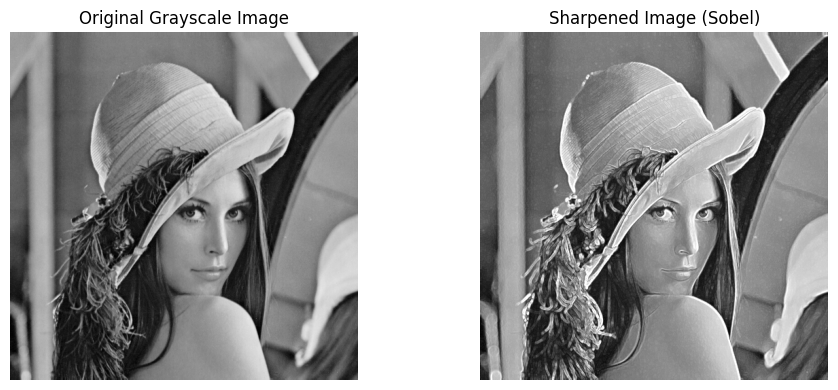

In [7]:
"""
Display original and sharpened images side by side.
"""

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Grayscale Image")
plt.imshow(gray_image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Sharpened Image (Sobel)")
plt.imshow(sharpened_image, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


### Discussion (Baseline)

The Sobel operator successfully highlights intensity transitions
corresponding to image edges. By adding the normalized gradient magnitude
to the original image, regions with strong edges become brighter,
resulting in a visually sharpened image.

This approach enhances edge contrast without explicitly modifying
flat regions, making it a simple yet effective sharpening technique.


## Part 2: Extended Edge Sharpening Analysis

While the baseline Sobel sharpening meets the exercise requirements,
additional analysis can provide deeper insight into edge behavior,
noise sensitivity, and sharpening control.

The following extensions explore these aspects in a structured manner.


### Sharpening Gain Control

To control sharpening intensity, a scaling factor α is introduced:

Sharpened = I + α · |∇I|

This allows analysis of under-sharpening and over-sharpening effects.


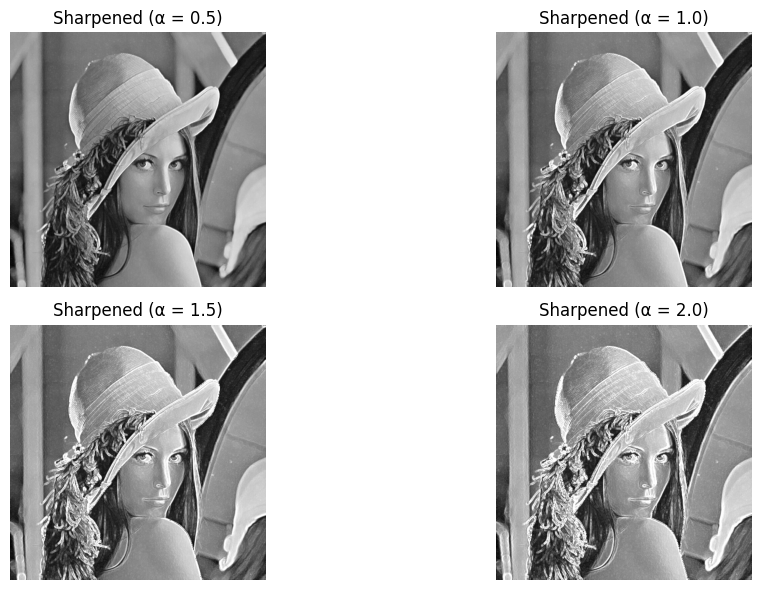

In [8]:
"""
Apply sharpening with different gain values.
"""

alpha_values = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(12, 6))

for i, alpha in enumerate(alpha_values):
    sharpened_alpha = cv2.add(
        gray_image,
        (alpha * gradient_u8).astype(np.uint8)
    )

    plt.subplot(2, 2, i + 1)
    plt.title(f"Sharpened (α = {alpha})")
    plt.imshow(sharpened_alpha, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Discussion

Increasing the sharpening gain enhances edge contrast but may introduce
visual artifacts such as halos and noise amplification.
This demonstrates the trade-off between edge enhancement and visual stability.


### Pre-smoothing Before Sobel

Applying a mild Gaussian blur before Sobel computation reduces
noise amplification during sharpening.


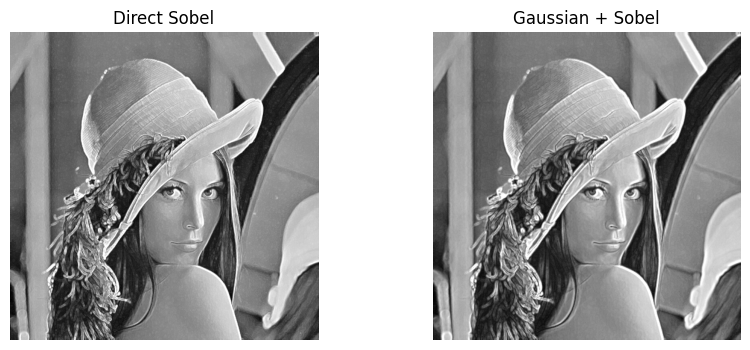

In [9]:
"""
Noise-aware Sobel sharpening using pre-smoothing.
"""

smoothed = cv2.GaussianBlur(gray_image, (5, 5), 1.0)

gx_s = cv2.Sobel(smoothed, cv2.CV_64F, 1, 0, ksize=3)
gy_s = cv2.Sobel(smoothed, cv2.CV_64F, 0, 1, ksize=3)

grad_s = np.sqrt(gx_s**2 + gy_s**2)
grad_s_norm = cv2.normalize(grad_s, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

sharpened_smooth = cv2.add(gray_image, grad_s_norm)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Direct Sobel"); plt.imshow(sharpened_image, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2); plt.title("Gaussian + Sobel"); plt.imshow(sharpened_smooth, cmap="gray"); plt.axis("off")
plt.show()


### Final Discussion

Pre-smoothing improves edge stability by suppressing noise before
derivative computation. Although edge strength is slightly reduced,
the overall sharpening result is more visually consistent.

This confirms the importance of noise-aware processing when using
gradient-based sharpening techniques.


## Conclusion

This notebook implemented Sobel-based edge sharpening starting from a
baseline solution that strictly follows the exercise requirements.
Subsequent extensions demonstrated controlled sharpening, noise-aware
processing, and analytical interpretation of edge enhancement behavior.

Such stepwise extension transforms a basic image processing task into
a structured and insightful analysis.
